### Import Modules

In [50]:
import pandas as pd,numpy as np
from sklearn.svm import SVC,LinearSVC,NuSVC
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold,GridSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler,normalize
from sklearn.metrics import accuracy_score,classification_report
import joblib
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

### Load Dataset

In [39]:
data = pd.read_csv("./embeddings_result/embeddings_call_graph_clusters_v2.csv")
data['code_file'] = data['code_file'].apply(lambda x: x.replace('/root/AI-Pattern-Mining-Project/outputs/prompt & rag/20251028_085918 - Run/generated_code/',''))
data['pattern'] = data['code_file'].apply(lambda x: x.split('/')[0])

In [40]:
data.head()

,code_file,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_759,dim_760,dim_761,dim_762,dim_763,dim_764,dim_765,dim_766,dim_767,pattern
0,Advanced MT Prompting/pattern_1.py,0.008525,-0.190404,-0.002678,0.109558,-0.149338,-0.015497,-0.002739,-0.163714,0.035823,...,-0.020440,-0.034098,0.127237,0.034867,0.036119,0.396191,-0.162014,-0.008755,0.192776,Advanced MT Prompting
1,Advanced MT Prompting/pattern_10.py,0.003148,-0.154247,-0.018378,0.109571,-0.133392,-0.027548,0.018564,-0.133213,0.030589,...,-0.019897,-0.051971,0.127128,0.066161,0.025146,0.391820,-0.205718,0.014096,0.121679,Advanced MT Prompting
2,Advanced MT Prompting/pattern_11.py,-0.000473,-0.199095,-0.024379,0.095847,-0.138792,-0.012554,0.002148,-0.176035,0.042417,...,-0.024046,-0.045352,0.143503,0.057276,0.029717,0.420159,-0.237789,0.003915,0.154167,Advanced MT Prompting
3,Advanced MT Prompting/pattern_12.py,0.016030,-0.193469,0.001521,0.100525,-0.102650,-0.121538,0.017241,-0.197112,0.069094,...,0.019782,-0.054770,0.114624,0.046622,0.047399,0.395274,-0.168212,-0.044403,0.211058,Advanced MT Prompting
4,Advanced MT Prompting/pattern_13.py,0.004324,-0.220477,-0.005859,0.139539,-0.176770,-0.052713,0.009045,-0.183556,0.044746,...,-0.030576,-0.018828,0.140990,0.034613,0.046899,0.453001,-0.168210,-0.032149,0.211387,Advanced MT Prompting


### Helper Functions

In [41]:
def print_scores(y_test, y_pred,target_names):
    print(classification_report(y_test, y_pred, target_names=target_names))

### Preprocess Data

In [42]:
le = LabelEncoder()
data['pattern_encoded'] = le.fit_transform(data['pattern'])
features_cols = [col for col in data.columns if col not in ['code_file','pattern','pattern_encoded']]

In [43]:
X = data[features_cols]
y = data['pattern_encoded']
# X = normalize(X)
scaler = StandardScaler()
X = scaler.fit_transform(X)


### Feature Selection

In [44]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(f_classif, k=442)
selector.fit(X, y)
X_feature_selected = selector.transform(X)

### Dimentionality Reductions

#### PCA

In [57]:
pc = PCA(n_components=400, random_state=1)
X_pca = pc.fit_transform(X_feature_selected)

#### UMAP

In [58]:
umap = UMAP(n_components=400, random_state=1)
X_umap = umap.fit_transform(X_pca)

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Train Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### SVC Exp

In [8]:
svc_model = SVC(kernel='linear', probability=True, random_state=42)
svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)
print_scores(y_test, svc_pred, target_names=le.classes_)

                                                                           precision    recall  f1-score   support

                                                    Advanced MT Prompting       1.00      0.67      0.80         6
                                         Bias Mitigation & Output Quality       0.86      1.00      0.92         6
                                              Cross-lingual LLM Prompting       0.86      1.00      0.92         6
                                       Enhanced User Intent Comprehension       0.86      1.00      0.92         6
                                          Explainable AI (XAI) Techniques       1.00      1.00      1.00         6
                                          Integrating External Knlowladge       0.29      0.33      0.31         6
                                             Integrating Knlowladge Graph       1.00      0.83      0.91         6
                                        Iterative Optimizations and ReAct      

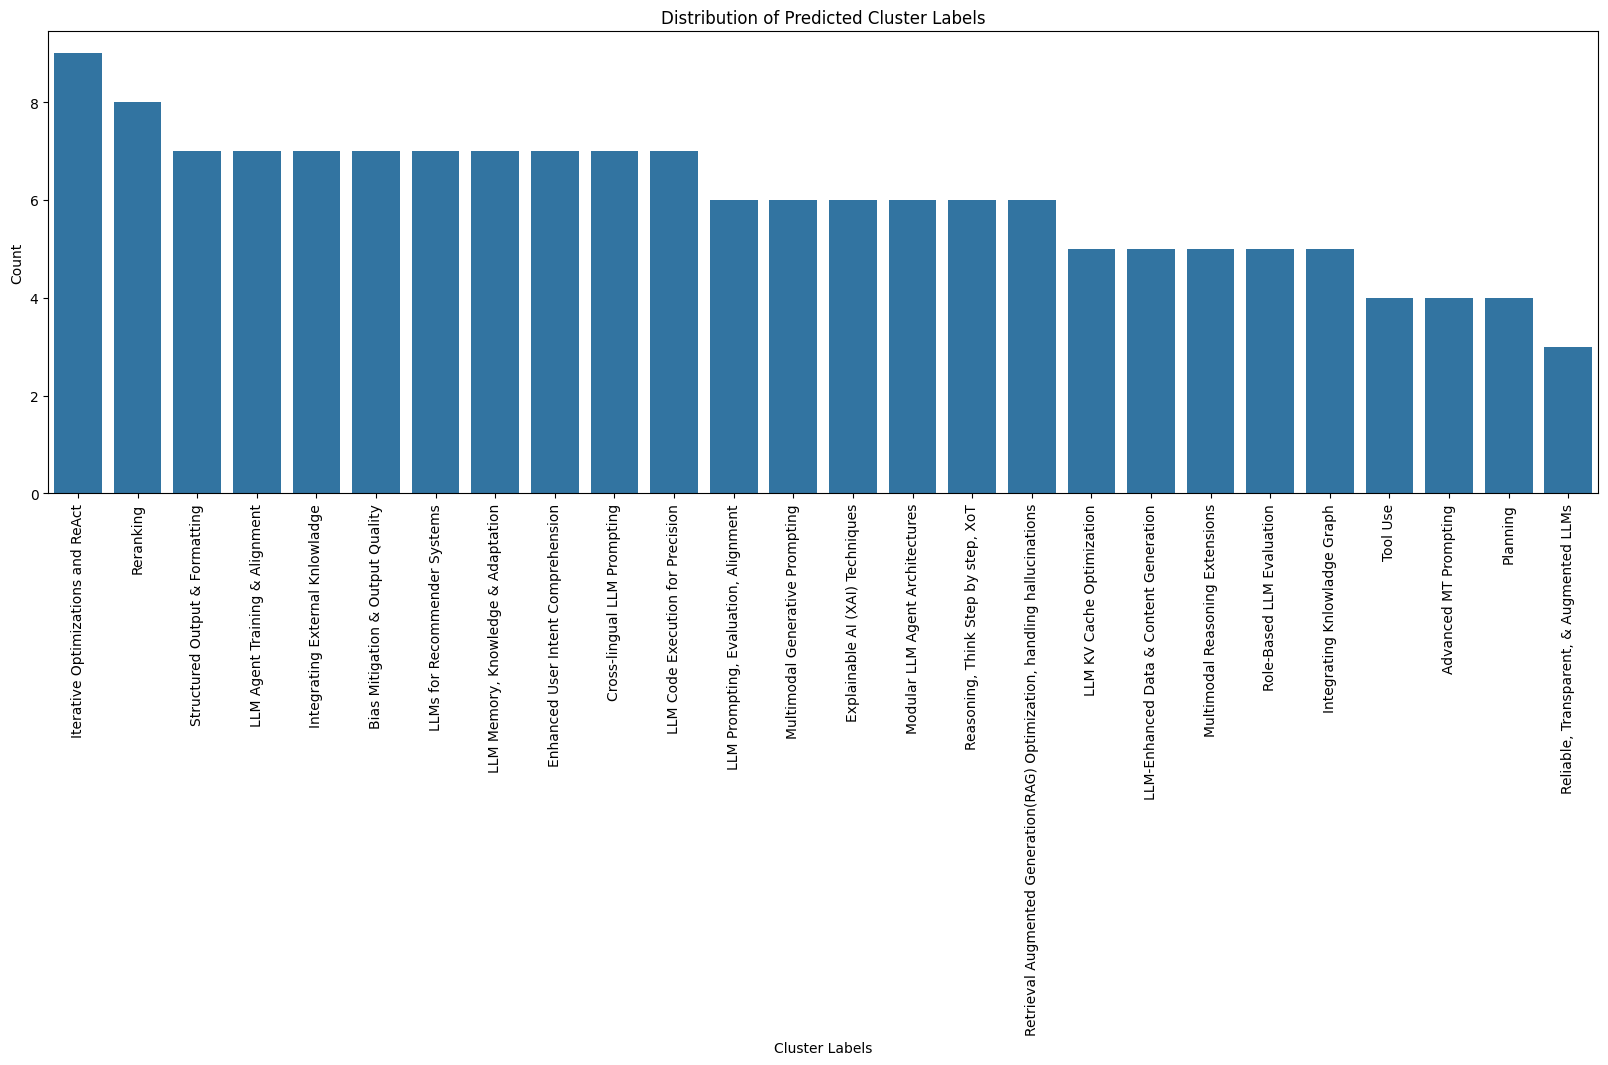

In [9]:
plt.figure(figsize=(20,6))
sns.countplot(x=le.inverse_transform(svc_pred), order=pd.Series(le.inverse_transform(svc_pred)).value_counts().index)
plt.title('Distribution of Predicted Cluster Labels')
plt.xlabel('Cluster Labels')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [10]:
params_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma':[1,0.1,0.01,0.001,'scale','auto']
}

grid = GridSearchCV(SVC(),param_grid=params_grid,refit=True,cv=5,verbose=2)
grid.fit(X_train, y_train)
print("Best Parameters:",grid.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.1s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.1s
[CV] END ........................C=0.1, gamma=1

KeyboardInterrupt: 

In [11]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2,)
svc_cv_scores = cross_val_score(svc_model, X, y, cv=kf, scoring='f1_weighted',)
print(f"SVC Cross-Validation F1 Scores: {svc_cv_scores}")
print(f"SVC Mean CV F1 Score: {np.mean(svc_cv_scores)}")

SVC Cross-Validation F1 Scores: [0.79473398 0.78937665 0.78577448 0.76057628 0.80617798]
SVC Mean CV F1 Score: 0.7873278757441653


### Other Model EXP

In [32]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)

In [ ]:
scores = {}
def model_eval(model,name='',X=X,y=y,tag='original'):
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='f1_weighted')
    if name not in scores:
        scores[name] = {}
    scores[name][tag] = cv_scores
    print(f"Summary of model: ")
    print(f" - {name} Cross-Validation F1 Scores: {cv_scores}")
    print(f" - {name} Mean CV F1 Score: {np.mean(cv_scores)}")

def run_evalutions(X,y,tag='original'):
    models = [
        (KNeighborsClassifier(n_neighbors=2), 'KNN'),
        (RandomForestClassifier(n_estimators=26, random_state=1), 'Random Forest'),
        (DecisionTreeClassifier(random_state=1), 'Decision Tree'),
        (SVC(kernel='linear', probability=True, random_state=42), 'SVC Linear'),
        (SVC(kernel='rbf', probability=True, random_state=42), 'SVC RBF'),
    ]
    for model, name in models:
        model_eval(model, name=name, X=X, y=y,tag=tag)

In [59]:
print("="*50+"\n"+"Evaluations on Original Features:")
run_evalutions(X,y)
print("="*50+"\n"+"Evaluations on Feature Selected Features:")
run_evalutions(X_feature_selected,y)

Evaluations on Original Features:
Summary of model: 
 - KNN Cross-Validation F1 Scores: [0.51820784 0.58215887 0.52647868 0.53597409 0.56386543]
 - KNN Mean CV F1 Score: 0.5453369788503154
Summary of model: 
 - Random Forest Cross-Validation F1 Scores: [0.57239993 0.58776096 0.54867822 0.59805111 0.60019772]
 - Random Forest Mean CV F1 Score: 0.581417586937949
Summary of model: 
 - Decision Tree Cross-Validation F1 Scores: [0.34927226 0.33843422 0.35229135 0.32819253 0.40933252]
 - Decision Tree Mean CV F1 Score: 0.35550457712222416
Summary of model: 
 - SVC Linear Cross-Validation F1 Scores: [0.80341686 0.80507249 0.79158598 0.71550832 0.83789608]
 - SVC Linear Mean CV F1 Score: 0.7906959443271661
Summary of model: 
 - SVC RBF Cross-Validation F1 Scores: [0.74330819 0.7033268  0.7341415  0.70210841 0.72462834]
 - SVC RBF Mean CV F1 Score: 0.7215026476791182
Evaluations on Feature Selected Features:
Summary of model: 
 - KNN Cross-Validation F1 Scores: [0.51694555 0.59518033 0.5676902 

In [60]:
print("="*50+"\n"+"Evaluations on PCA Features:")
run_evalutions(X_pca,y)
print("="*50+"\n"+"Evaluations on UMAP Features:")
run_evalutions(X_umap,y)

Evaluations on PCA Features:
Summary of model: 
 - KNN Cross-Validation F1 Scores: [0.51694555 0.59518033 0.5676902  0.54833797 0.56831448]
 - KNN Mean CV F1 Score: 0.5592937081617719
Summary of model: 
 - Random Forest Cross-Validation F1 Scores: [0.50745477 0.42104336 0.46761501 0.42011066 0.44839076]
 - Random Forest Mean CV F1 Score: 0.45292291181074223
Summary of model: 
 - Decision Tree Cross-Validation F1 Scores: [0.33759589 0.41122937 0.35757586 0.32252971 0.36632234]
 - Decision Tree Mean CV F1 Score: 0.3590506353348697
Summary of model: 
 - SVC Linear Cross-Validation F1 Scores: [0.79473398 0.78937665 0.78577448 0.76057628 0.80617798]
 - SVC Linear Mean CV F1 Score: 0.7873278757441653
Summary of model: 
 - SVC RBF Cross-Validation F1 Scores: [0.7532316  0.70763339 0.72934501 0.70502147 0.75829211]
 - SVC RBF Mean CV F1 Score: 0.7307047176051701
Evaluations on UMAP Features:
Summary of model: 
 - KNN Cross-Validation F1 Scores: [0.41874    0.43756201 0.4152337  0.4884349  0.46

#### KNeighbors Classifier

In [45]:
model = KNeighborsClassifier(n_neighbors=2)
model_eval(model, name='KNN')

Summary of model: 
 - KNN Cross-Validation F1 Scores: [0.51820784 0.58215887 0.52647868 0.53597409 0.56386543]
 - KNN Mean CV F1 Score: 0.5453369788503154


In [46]:
model = RandomForestClassifier(n_estimators=26, random_state=1)
model_eval(model, name='Random Forest')

Summary of model: 
 - Random Forest Cross-Validation F1 Scores: [0.57239993 0.58776096 0.54867822 0.59805111 0.60019772]
 - Random Forest Mean CV F1 Score: 0.581417586937949


In [47]:
model = DecisionTreeClassifier(random_state=1)
model_eval(model)

Summary of model: 
 -  Cross-Validation F1 Scores: [0.34927226 0.33843422 0.35229135 0.32819253 0.40933252]
 -  Mean CV F1 Score: 0.35550457712222416


### Final SVC Model Build and Save

In [12]:
final_svc_model = SVC(kernel='linear', probability=True, random_state=42)
final_svc_model.fit(X, y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [13]:
pipeline = Pipeline(steps=[('scaler', scaler), ('selector', selector), ('svc', final_svc_model)])

In [14]:
predictions = pipeline.predict(data[features_cols])
accuracy = accuracy_score(y, predictions)
print(f"Overall Accuracy on entire dataset: {accuracy}")

Overall Accuracy on entire dataset: 1.0


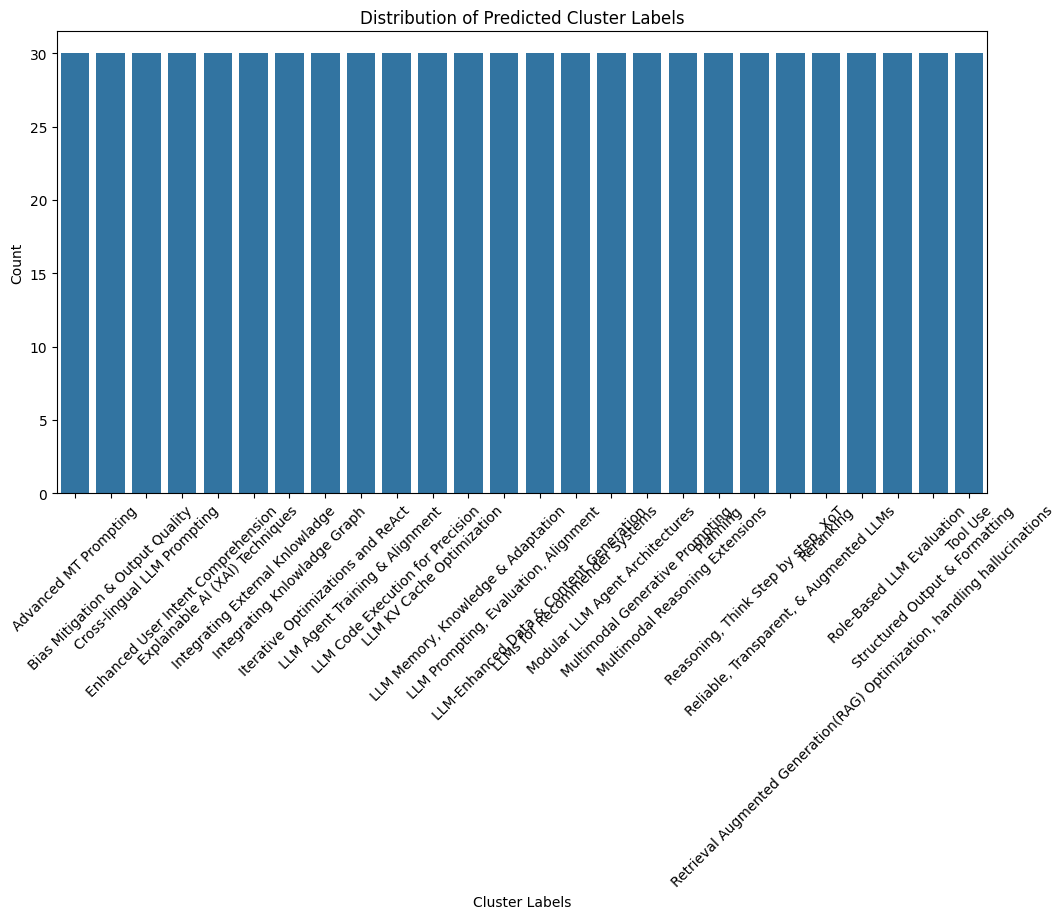

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(x=le.inverse_transform(predictions), order=pd.Series(le.inverse_transform(predictions)).value_counts().index)
plt.title('Distribution of Predicted Cluster Labels')
plt.xlabel('Cluster Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [16]:
joblib.dump(pipeline, './models/svc_classification_pipeline_v2.joblib')
joblib.dump(le, './models/label_encoder_v2.joblib')

['./models/label_encoder_v2.joblib']

### Clasify

In [17]:
t_data = pd.read_csv("../data/raw/repos/embeddings_call_graph_clusters.csv")
t_data['code_file'] = t_data['cluster_file'].apply(lambda x: x.replace('./result/repo_callgraph_clusters/', ''))

In [18]:
feature_cols = [col for col in t_data.columns if col not in ['cluster_file', 'code_file', 'cluster_label']]
features = t_data[feature_cols]

In [19]:
t_X = scaler.transform(features)
t_X = selector.transform(t_X)
predictions = final_svc_model.predict_proba(t_X)
_predictions = final_svc_model.predict(t_X)
predicted_labels = le.inverse_transform(_predictions)

In [20]:
import json
llm_result = json.load(open('result/predicted_clusters_verification_results.json'))

In [21]:
np.max(predictions, axis=1)

array([0.41447371, 0.36139499, 0.38159911, ..., 0.116182  , 0.2844901 ,
       0.4539926 ], shape=(2442,))

In [22]:
t_data['prediction_prob'] = np.max(predictions, axis=1)
t_data['prediction'] = predicted_labels

In [23]:
prediction_prob_dict = {}
for idx, row in t_data.iterrows():
    prediction_prob_dict[row['code_file']] = (row['prediction_prob'], row['prediction'])

In [24]:
for item in llm_result.keys():
    llm_result[item]['prediction_prob'] = prediction_prob_dict.get(item, None)[0]
    llm_result[item]['prediction'] = prediction_prob_dict.get(item, None)[1]

In [25]:
confident_list = []
for item in llm_result.keys():
    confident_list.append((llm_result[item]['prediction_prob'],llm_result[item]['verification_result']['score'],llm_result[item]['verification_result']['is_correct'],llm_result[item]['prediction']))

In [26]:
confident_list

[(0.41447370955882623, 9, False, 'Explainable AI (XAI) Techniques'),
 (0.361394989098087, 10, False, 'Explainable AI (XAI) Techniques'),
 (0.38159911103030114, 9, False, 'Explainable AI (XAI) Techniques'),
 (0.2527173488938815,
  10,
  False,
  'Retrieval Augmented Generation(RAG) Optimization, handling hallucinations'),
 (0.4648704178782096, 9, False, 'LLM Code Execution for Precision'),
 (0.5153032033070358, 9, False, 'Explainable AI (XAI) Techniques'),
 (0.5173171947020833, 9, False, 'Explainable AI (XAI) Techniques'),
 (0.571521692139939, 7, False, 'LLM Code Execution for Precision'),
 (0.5154492437046649, 9, False, 'LLM Code Execution for Precision'),
 (0.4125012299048456, 10, False, 'Explainable AI (XAI) Techniques'),
 (0.28662496111060765, 9, True, 'Multimodal Reasoning Extensions'),
 (0.3662429839385204, 9, False, 'LLM KV Cache Optimization'),
 (0.16870115011802456, 2, False, 'LLM KV Cache Optimization'),
 (0.19964709456595056, 8, False, 'Integrating External Knlowladge'),
 (0.

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

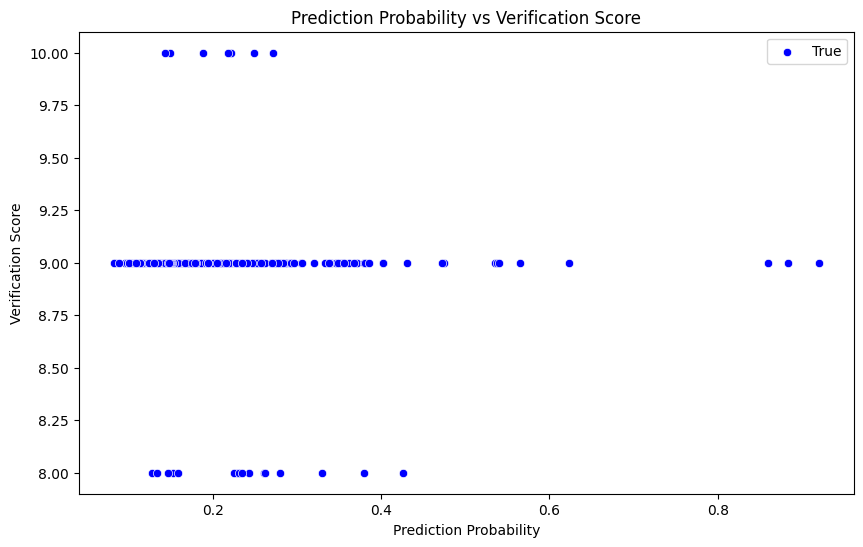

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

true_points  = [x for x in confident_list if x[2] == True]
false_points = [x for x in confident_list if x[2] == False]

plt.figure(figsize=(10,6))

# sns.scatterplot(
#     x=[x[0] for x in false_points],
#     y=[x[1] for x in false_points],
#     color='red',
#     # alpha=0.2,
#     label='False',
#     zorder=1
# )

sns.scatterplot(
    x=[x[0] for x in true_points],
    y=[x[1] for x in true_points],
    color='blue',
    alpha=1,
    label='True',
    zorder=2
)

plt.title('Prediction Probability vs Verification Score')
plt.xlabel('Prediction Probability')
plt.ylabel('Verification Score')
plt.legend()
plt.show()


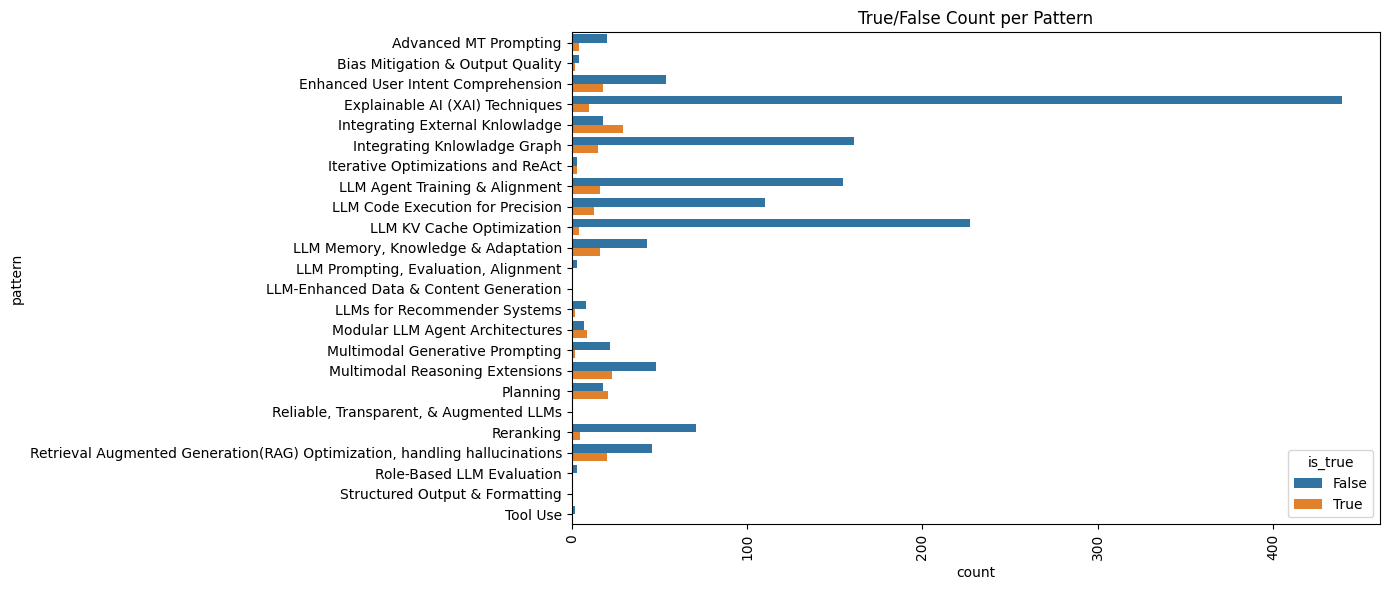

In [67]:
import pandas as pd

df = pd.DataFrame(confident_list, columns=[
    "probability", "number", "is_true", "pattern"
])

patterns = df["pattern"].unique()
counts = df.groupby(["pattern", "is_true"]).size().reset_index(name="count")

plt.figure(figsize=(14,6))

sns.barplot(
    data=counts,
    y="pattern",
    x="count",
    hue="is_true"
)

plt.xticks(rotation=90)
plt.title("True/False Count per Pattern")
plt.tight_layout()
plt.show()